#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> PCA (Principal Component Analysis)

General Concept:

Dimensionality reduction refers to transforming data with a large number of features into a lower-dimensional space while preserving important information as much as possible.

Why is Dimensionality Reduction important?
1. Visualization
Humans can easily visualize data only in 2D and 3D.

2. Reducing Computational Cost
Data with fewer features:
- Trains faster.
- Consumes less memory.

3. Noise Removal
Some features:
- Contain little information.
- Introduce noise.
Dimensionality reduction can eliminate these components.

4. Avoiding the Curse of Dimensionality
In high dimensions:
- Distances lose their significance.
- Algorithms such as KNN and clustering become more difficult to execute.

**The idea behind PCA:**

Finding the directions that explain the greatest variance in the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from src.pca import PCA

from sklearn.decomposition import PCA as SKPCA

<h3> Step 1: Initial Test on Iris

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

In [3]:
print("X_pca.shape: \n", X_pca.shape)
print("\npca.components: \n", pca.components)
print("\npca.explained_variance: \n", pca.explained_variance)
print("\npca.explained_variance_ratio: \n", pca.explained_variance_ratio)


X_pca.shape: 
 (150, 2)

pca.components: 
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]]

pca.explained_variance: 
 [2.93808505 0.9201649 ]

pca.explained_variance_ratio: 
 [0.72962445 0.22850762]


<h3> Step 2: Compare with Scikit-Learn PCA

In [4]:
sk_pca = SKPCA(
    n_components=2
)

X_pca_sk = sk_pca.fit_transform(
    X_scaled
)

print(
    X_pca_sk.shape
)

(150, 2)


In [5]:
print(
    pca.components
)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]]


In [6]:
print(
    sk_pca.components_
)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [7]:
print(
    pca.explained_variance_ratio
)

[0.72962445 0.22850762]


In [8]:
print(
    sk_pca.explained_variance_ratio_
)

[0.72962445 0.22850762]


In [9]:
print(
    np.abs(
        X_pca[:5]
    )
)

print(
    np.abs(
        X_pca_sk[:5]
    )
)

[[2.26470281 0.4800266 ]
 [2.08096115 0.67413356]
 [2.36422905 0.34190802]
 [2.29938422 0.59739451]
 [2.38984217 0.64683538]]
[[2.26470281 0.4800266 ]
 [2.08096115 0.67413356]
 [2.36422905 0.34190802]
 [2.29938422 0.59739451]
 [2.38984217 0.64683538]]


<h3> Step 3: Visualization PCA

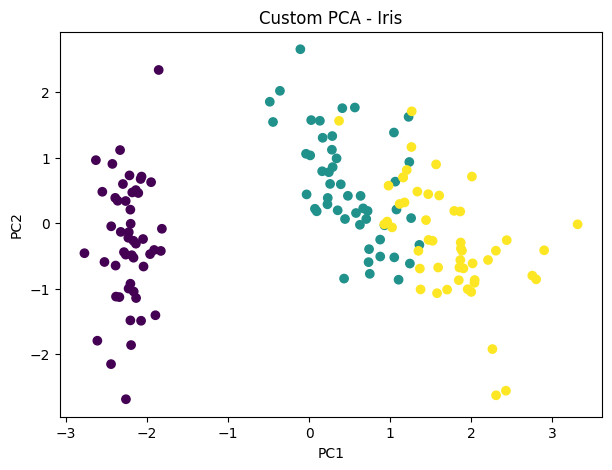

In [10]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.title(
    "Custom PCA - Iris"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.show()

In [11]:
X_reconstructed = pca.inverse_transform(
    X_pca
)

In [12]:
mse = np.mean(
    (X_scaled - X_reconstructed)**2
)

print(
    mse
)

0.041867927999983595


### Principal Component Analysis (PCA)

#### Overview

Principal Component Analysis is a linear dimensionality reduction technique that transforms high-dimensional data into a smaller number of principal components while preserving the maximum possible variance.

PCA creates new features called principal components, which are linear combinations of the original features.

---

#### Algorithm Steps

1. Center the data by subtracting feature means.

2. Calculate the covariance matrix.

3. Perform eigenvalue decomposition:
   - Eigenvectors represent principal component directions.
   - Eigenvalues represent explained variance.

4. Sort components based on eigenvalues.

5. Select the top components and transform the data.

---

#### Implementation

A custom PCA implementation was created with:

- Data centering
- Covariance matrix calculation
- Eigen decomposition
- Component selection
- Explained variance calculation
- Data transformation
- Reconstruction

The implementation was compared with:

```python
sklearn.decomposition.PCA

Iris Dataset Results
The original Iris dataset contains:
150 samples
4 features

After applying PCA:
150 samples
2 principal components

The explained variance ratio was:
Component	Variance
PC1	72.96%
PC2	22.85%


Together, the first two components preserve:
95.81% of the original variance

Conclusion
PCA successfully reduced the dimensionality of the Iris dataset while preserving most of the important information.
The visualization showed clear separation of Setosa, while Versicolor and Virginica remained partially overlapping due to their similar feature distributions.